In [1]:
!pip install shap xgboost pyarrow tensorflow --quiet

In [4]:
import numpy as np
import pandas as pd
import pickle

import matplotlib.pyplot as plt
import seaborn as sns

import shap
import tensorflow as tf

plt.style.use("default")
sns.set_style("whitegrid")


In [2]:
!ls


autoencoder_full.pkl  final_model.pkl  sample_data  X_test_selected.parquet


In [5]:
with open("final_model.pkl", "rb") as f:
    xgb_model = pickle.load(f)

with open("autoencoder_full.pkl", "rb") as f:
    ae_artifacts = pickle.load(f)

autoencoder = ae_artifacts["model"]
scaler = ae_artifacts["scaler"]
feature_columns = ae_artifacts["feature_columns"]

print("Models loaded successfully")
X_test = pd.read_parquet("X_test_selected.parquet")

print("X_test shape:", X_test.shape)
X_test.head()


/tmp/ipython-input-1249170861.py:2: UserWarning: [06:23:47] WARNING: /workspace/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  xgb_model = pickle.load(f)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Models loaded successfully
X_test shape: (116899, 48)


,bwd_iat_min,fwd_iat_min,down/up_ratio,flow_iat_std,bwd_iat_mean,fwd_packet_skew,urg_flag_count,proto_0,flow_bytes/s,packet_length_min,...,active_cv,fwd_header_length,fwd_packet_length_max,total_flag_count,packet_rate,packet_entropy,flow_packets/s,fin_flag_count,packet_length_variance,flow_iat_min
0,0.0,3.0,0.0,8.476089e+03,0.0,0.577350,0.0,0.0,3585.424831,6.0,...,0.0,60.0,31.0,1.0,250.229300,2.438133e-09,250.145918,0.0,156.250000,3.0
1,0.0,2.0,0.0,1.924829e+06,0.0,0.000000,0.0,0.0,7.185790,6.0,...,0.0,80.0,6.0,1.0,1.197931,1.000000e+00,1.197632,0.0,0.000000,2.0
2,0.0,1.0,0.0,5.600306e+02,0.0,0.499998,0.0,0.0,6147.540984,0.0,...,0.0,116.0,6.0,1.0,4099.385246,1.097500e-08,4098.360656,0.0,7.200000,1.0
3,0.0,49.0,0.0,1.763423e+06,0.0,1.043498,0.0,0.0,44.676675,6.0,...,0.0,100.0,46.0,2.0,1.481242,1.772503e-09,1.480995,0.0,355.952393,49.0
4,0.0,9984930.0,0.0,0.000000e+00,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,64.0,0.0,1.0,0.200402,1.000000e+00,0.200302,0.0,0.000000,9984930.0


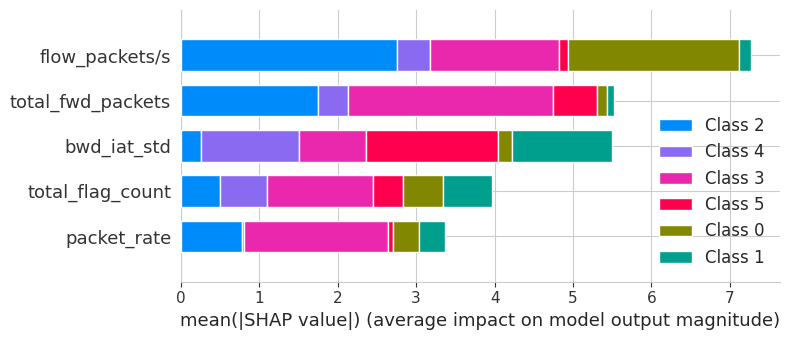

In [7]:
X_shap = X_test.sample(5000, random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)

# Global importance (multiclass-safe)
mean_shap = np.abs(shap_values).mean(axis=(0, 2))

shap_importance = pd.DataFrame({
    "feature": X_shap.columns,
    "importance": mean_shap
}).sort_values(by="importance", ascending=False)

top5_shap = shap_importance.head(5)
top5_shap

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    max_display=5,
    show=True
)

sample_idx = 0

# FIX: choose class with max absolute SHAP contribution
pred_class = np.abs(shap_values[sample_idx]).mean(axis=0).argmax()

shap.force_plot(
    explainer.expected_value[pred_class],
    shap_values[sample_idx, :, pred_class],
    X_shap.iloc[sample_idx]
)


In [8]:
def compute_ae_feature_deviation(sample_df):
    x_scaled = scaler.transform(sample_df)
    x_reconstructed = autoencoder.predict(x_scaled, verbose=0)

    deviation = np.abs(x_scaled - x_reconstructed)[0]

    return pd.DataFrame({
        "feature": feature_columns,
        "deviation": deviation
    }).sort_values(by="deviation", ascending=False)
sample = X_test.iloc[[0]]

ae_deviation = compute_ae_feature_deviation(sample)
top5_ae = ae_deviation.head(5)

top5_ae


,feature,deviation
20,burst_ratio,0.244882
30,flag_change_rate,0.201329
16,fwd_iat_cv,0.140679
6,urg_flag_count,0.117555
43,packet_entropy,0.115998


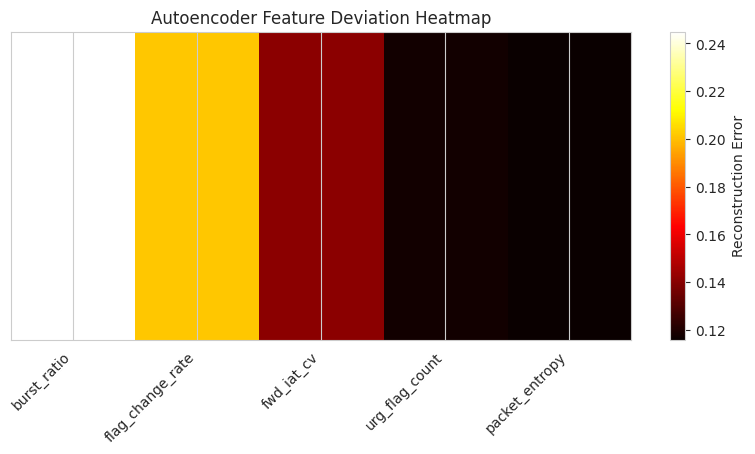

In [9]:
plt.figure(figsize=(10, 4))
plt.imshow(
    top5_ae["deviation"].values.reshape(1, -1),
    cmap="hot",
    aspect="auto"
)
plt.yticks([])
plt.xticks(
    range(len(top5_ae)),
    top5_ae["feature"],
    rotation=45,
    ha="right"
)
plt.colorbar(label="Reconstruction Error")
plt.title("Autoencoder Feature Deviation Heatmap")
plt.show()


In [10]:
def generate_explanation(shap_df, ae_df, attack_label):
    shap_features = ", ".join(shap_df["feature"].values[:2])
    ae_features = ", ".join(ae_df["feature"].values[:2])

    return (
        f"The network flow was classified as {attack_label} due to high influence "
        f"from features such as {shap_features}. "
        f"Additionally, abnormal behavior was detected in "
        f"{ae_features}, which deviated significantly from normal traffic patterns."
    )
attack_label = "DoS"  # example
explanation_text = generate_explanation(top5_shap, top5_ae, attack_label)

print(explanation_text)


The network flow was classified as DoS due to high influence from features such as flow_packets/s, total_fwd_packets. Additionally, abnormal behavior was detected in burst_ratio, flag_change_rate, which deviated significantly from normal traffic patterns.
